<a href="https://colab.research.google.com/github/guilhermelaviola/ApplicationOfDataScienceForBusiness/blob/main/Class08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Metrics for Classification**
Data quality is fundamental in machine learning, as inconsistent, incomplete, or biased data can produce unreliable models and poor decisions. Preparing data through cleaning and transformation—using tools like OpenRefine—ensures it is suitable for training algorithms such as XGBoost Classifier, which can be applied to tasks like employee turnover prediction or wine classification. Model performance must be evaluated carefully using metrics derived from the confusion matrix, including precision, recall, accuracy, and F1-score, since accuracy alone may be misleading, especially with imbalanced classes. Cross-validation further strengthens model reliability by testing its ability to generalize to unseen data and reducing overfitting. Additionally, identifying and handling anomalies and noise—through visualization techniques like scatter plots and proper cleaning methods—is essential to maintain data integrity. Overall, building effective classification models requires strong data preparation, appropriate algorithm choice, comprehensive metric evaluation, and careful treatment of irregularities in the dataset.

In [9]:
# Importing all the necessary libraries and resources:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

## **Example: Advanced Model Classification Metrics in Business**
Here we explore more advanced metrics, such as the confusion matrix and the F1-score, among others. We will understand the construction of these metrics and how to apply them appropriately in different situations. Here we import pandas and configured our workspace with scikit-learn. We used the train_test_split function to split our data and employed the XGBoost Classifier algorithm, a machine learning algorithm that stands out for its robustness in evaluating multiple decision trees simultaneously.

In [10]:
# Loading and displaying a dataset from URL that contains fictional data for study purposes only:
url = 'https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv'
wines_df = pd.read_csv(url)
wines_df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [11]:
# Preprocessing the data:
wines_df = wines_df.dropna() # Removing null values
X = wines_df.drop('Wine', axis=1) # Predictor variables
y = wines_df['Wine'] # Target variable

# Divinding the data into training and test sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data standardization:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Creating the XGBoost classification model:
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [12]:
# Adjusting target labels to be 0-indexed as required by XGBoost
y_train_adjusted = y_train - 1
y_test_adjusted = y_test - 1

# Training the model:
model_xgb.fit(X_train, y_train_adjusted)

# Predictions on the test set:
predictions = model_xgb.predict(X_test)

# Evaluating the model:
accuracy = accuracy_score(y_test_adjusted, predictions)
precision = precision_score(y_test_adjusted, predictions, average='weighted')
recall = recall_score(y_test_adjusted, predictions, average='weighted')
f1 = f1_score(y_test_adjusted, predictions, average='weighted')

# Displaying the results
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')

Accuracy: 0.9444444444444444
Precision: 0.9513888888888888


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:23:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [13]:
print(f'Recall: {recall}')
print(f'F1-Score: {f1}')
print(f'Confusion Matrix:\n{confusion_matrix(y_test, predictions)}')
print(f'Classification Report:\n{classification_report(y_test, predictions)}')

Recall: 0.9444444444444444
F1-Score: 0.9448559670781892
Confusion Matrix:
[[ 0  0  0  0]
 [13  1  0  0]
 [ 0 14  0  0]
 [ 0  1  7  0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.06      0.07      0.07        14
           2       0.00      0.00      0.00        14
           3       0.00      0.00      0.00         8

    accuracy                           0.03        36
   macro avg       0.02      0.02      0.02        36
weighted avg       0.02      0.03      0.03        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

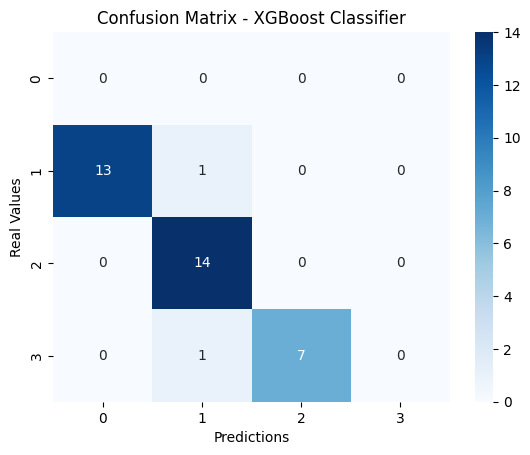

In [14]:
# Displaying the Confusion Matrix:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.xlabel('Predictions')
plt.ylabel('Real Values')
plt.show()

## **Example: Applying Metrics in Python for Business**
Now we may apply classification metrics in a business context using Python. We'll explore how to identify and handle anomalies and noise in data, and how this impacts performance metrics such as accuracy, recall, and precision.

Accuraies: [0.97222222 0.94444444 0.97222222 1.         0.97142857]
Scores average: 0.972063492063492


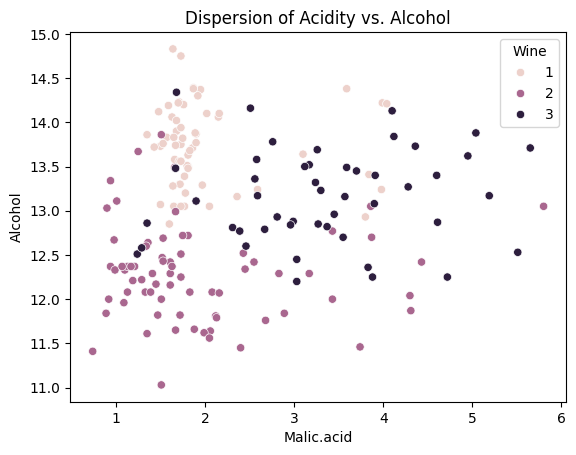

In [21]:
# Splitting data ivide into predictor and target variables:
X = wines_df.drop('Wine', axis=1)
y = wines_df['Wine']

# Initializing the model:
model = RandomForestClassifier()

# Performing cross-validation:
scores = cross_val_score(model, X, y, cv=5)

# Displaying the results:
print(f'Accuraies: {scores}')
print(f'Scores average: {scores.mean()}')

# Scatter visualization to identify anomalies:
sns.scatterplot(data=wines_df, x='Malic.acid', y='Alcohol', hue='Wine')
plt.title('Dispersion of Acidity vs. Alcohol')
plt.show()

## **Example: Anomaly and Noise Treatment**
Here we treat anomalies and noise in the data using cleaning techniques.

In [23]:
# Remover anomalias baseadas em um limiar
threshold = wines_df['Malic.acid'].quantile(0.95)
data_cleaned = wines_df[wines_df['Malic.acid'] < threshold]

# Noise treatment; normalization of values:
data_cleaned['State'] = data_cleaned['State'].replace({'N. York': 'NY', 'New York':'SP})

# Visualization of clean data:
sns.scatterplot(data=data_cleaned, x='Malic.acid', y='Alcohol", hue='target')
plt.title('Dispersion of Acidity and Alcohol (Clean Data)')
plt.show()

SyntaxError: unterminated string literal (detected at line 6) (ipython-input-1007769755.py, line 6)